Install Libraries

In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn

Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

Load dataset

In [4]:
df = pd.read_csv("/content/Advertising.csv")

df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


**Explore Dataset**

Check:
Missing values,
Data types,
Number of records

In [5]:
print(df.shape)

print(df.info())

print(df.describe())

print(df.isnull().sum())

(200, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB
None
       Unnamed: 0          TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000  200.000000
mean   100.500000  147.042500   23.264000   30.554000   14.022500
std     57.879185   85.854236   14.846809   21.778621    5.217457
min      1.000000    0.700000    0.000000    0.300000    1.600000
25%     50.750000   74.375000    9.975000   12.750000   10.375000
50%    100.500000  149.750000   22.900000   25.750000   12.900000
75%    150.250000  218.825000   36.525000   45.100000   17.400000
max    200.000000

**Data Cleaning**
Remove Missing Values

In [6]:
df.dropna(inplace=True)

Remove Duplicates

In [7]:
df.drop_duplicates(inplace=True)

**Correlation Matrix. **
Look for:
Advertising channels strongly related to sales
Positive/negative relationships

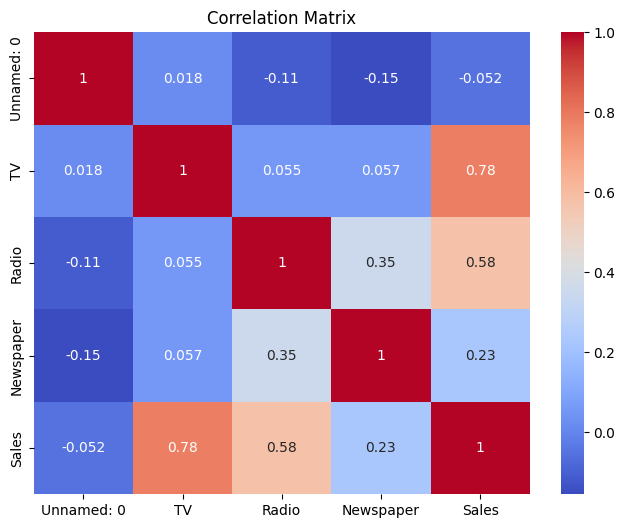

In [8]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

**Advertising Spend Distribution**

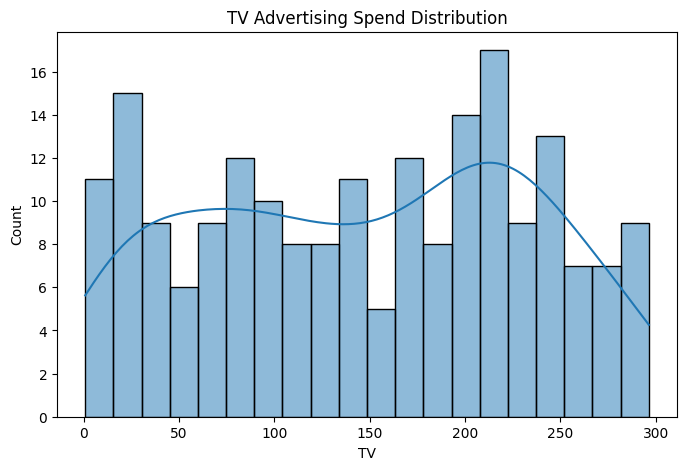

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df['TV'], bins=20, kde=True)
plt.title("TV Advertising Spend Distribution")
plt.show()

Sales **Distribution**

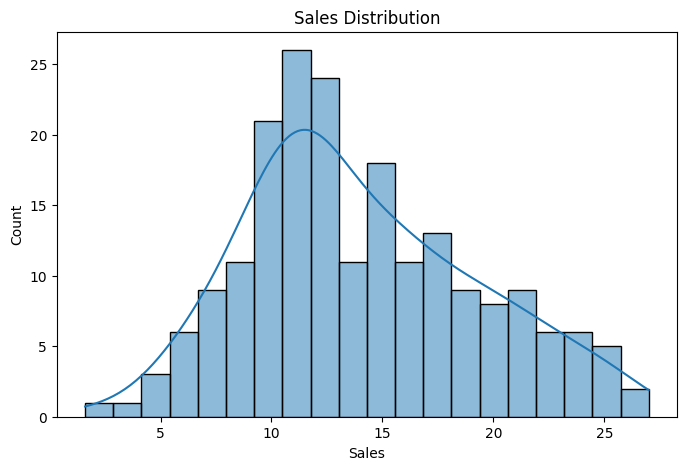

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df['Sales'], bins=20, kde=True)
plt.title("Sales Distribution")
plt.show()

**Analyze Advertising Impact**

TV vs Sales

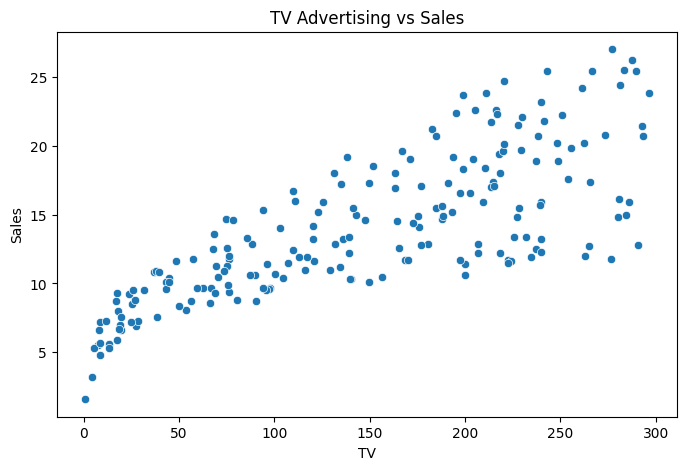

In [11]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='TV', y='Sales', data=df)

plt.title("TV Advertising vs Sales")
plt.show()

**Radio vs Sales**

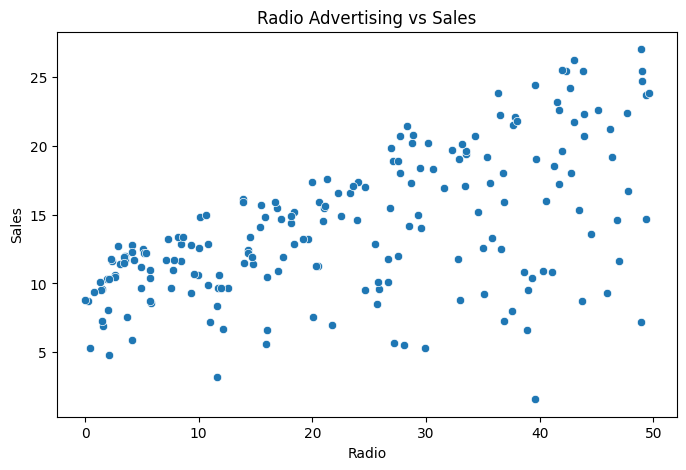

In [12]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Radio', y='Sales', data=df)

plt.title("Radio Advertising vs Sales")
plt.show()

**Newspaper vs Sales**

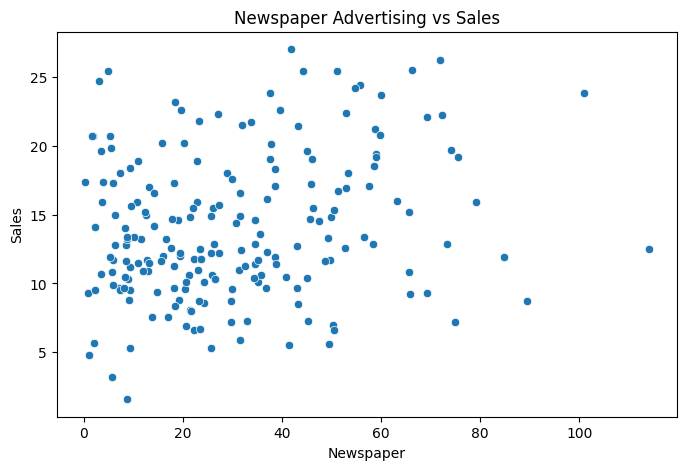

In [13]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Newspaper', y='Sales', data=df)

plt.title("Newspaper Advertising vs Sales")
plt.show()

**Feature Selection**

Input Variables

In [14]:
X = df[['TV', 'Radio', 'Newspaper']]

Target Variable

In [15]:
y = df['Sales']

**Split Dataset**

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

**Train Model**

Use Linear Regression.

In [17]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

Make Predictions

In [18]:
predictions = model.predict(X_test)

print(predictions[:10])

[16.4080242  20.88988209 21.55384318 10.60850256 22.11237326 13.10559172
 21.05719192  7.46101034 13.60634581 15.15506967]


**Evaluate Model**

MAE

In [19]:
mae = mean_absolute_error(y_test, predictions)

print("MAE:", mae)

MAE: 1.4607567168117603


RMSE

In [20]:
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("RMSE:", rmse)

RMSE: 1.78159966153345


**R² Score**
Very Good model quality

In [21]:
r2 = r2_score(y_test, predictions)

print("R2 Score:", r2)

R2 Score: 0.899438024100912


Compare Actual vs Predicted

In [22]:
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': predictions
})

print(results.head())

     Actual  Predicted
95     16.9  16.408024
15     22.4  20.889882
30     21.4  21.553843
158     7.3  10.608503
128    24.7  22.112373


Visualization

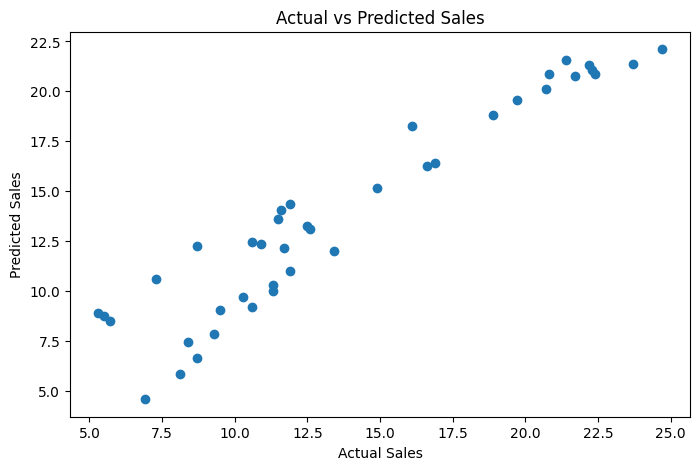

In [23]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Sales")

plt.show()

**Future Sales Prediction**

Predict sales for new advertising budget

In [24]:
new_campaign = [[250, 50, 30]]

future_sales = model.predict(new_campaign)

print("Predicted Sales:", future_sales[0])

Predicted Sales: 23.704032847261555


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


**Feature Importance Analysis**

Linear Regression coefficients show impact.

In [25]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print(importance)

     Feature  Coefficient
0         TV     0.044730
1      Radio     0.189195
2  Newspaper     0.002761


Visualize

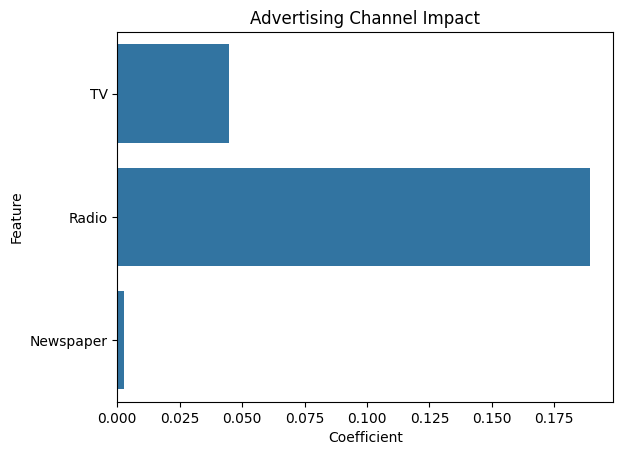

In [26]:
sns.barplot(
    x='Coefficient',
    y='Feature',
    data=importance
)

plt.title("Advertising Channel Impact")
plt.show()

In [27]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression

## 1. Introduction

### Problem Statement
This analysis aims to understand the relationship between advertising expenditure across different channels (TV, Radio, Newspaper) and sales, ultimately to predict future sales and provide recommendations for optimal budget allocation.

### Objectives
*   To explore the dataset and understand its characteristics.
*   To clean the data by handling missing values and duplicates.
*   To visualize distributions and correlations of advertising spend and sales.
*   To build a linear regression model to predict sales based on advertising spend.
*   To evaluate the model's performance using standard metrics (MAE, RMSE, R²).
*   To forecast sales for a new advertising campaign.
*   To identify the most effective advertising channels and provide budget allocation recommendations.

## 2. Dataset Description

### Features
The dataset contains the following features:
*   `Unnamed: 0`: An index column (likely redundant).
*   `TV`: Advertising spend on TV (in thousands of dollars).
*   `Radio`: Advertising spend on Radio (in thousands of dollars).
*   `Newspaper`: Advertising spend on Newspaper (in thousands of dollars).
*   `Sales`: Product sales (in thousands of units).

### Number of Records
The dataset contains **200 records** and **5 columns**.

## 3. Data Cleaning

### Missing values
The initial check revealed **no missing values** in any of the columns.

### Duplicates
No duplicate rows were found in the dataset, therefore **no rows were dropped** during the duplicate removal process.

## 4. Exploratory Data Analysis

### Distributions
*   **TV Advertising Spend Distribution**: The distribution of TV advertising spend shows a wide range, indicating varying levels of investment across different campaigns.
*   **Sales Distribution**: The sales distribution suggests a range of sales figures, with a central tendency that can be further analyzed for patterns.

### Correlations
The correlation matrix indicates:
*   **TV** advertising has a **strong positive correlation** with Sales (correlation coefficient: ~0.78).
*   **Radio** advertising also shows a **positive correlation** with Sales (correlation coefficient: ~0.58).
*   **Newspaper** advertising has a **very weak positive correlation** with Sales (correlation coefficient: ~0.23).

### Advertising Impact
*   **TV vs Sales**: The scatter plot shows a clear **linear positive relationship** between TV advertising spend and sales. As TV advertising increases, sales generally increase.
*   **Radio vs Sales**: A positive trend is observable, but with more scatter than TV, suggesting a moderate positive relationship.
*   **Newspaper vs Sales**: The relationship here appears much weaker and more dispersed, consistent with its low correlation coefficient.

## 5. Model Building

### Train-test split
The dataset was split into training and testing sets with a **20% test size** and a `random_state` of `42` for reproducibility.
*   **Training set (X_train, y_train)**: 160 samples
*   **Testing set (X_test, y_test)**: 40 samples

### Linear Regression
A Linear Regression model was initialized and trained using the `X_train` (TV, Radio, Newspaper spend) and `y_train` (Sales) datasets.

## 6. Model Evaluation

After making predictions on the test set, the model's performance was evaluated using the following metrics:

*   **Mean Absolute Error (MAE)**: `1.46`
    *   Interpretation: On average, the model's predictions are off by approximately 1.46 thousand units of sales.

*   **Root Mean Squared Error (RMSE)**: `1.78`
    *   Interpretation: The standard deviation of the residuals (prediction errors) is about 1.78 thousand units of sales. This gives a higher penalty to larger errors.

*   **R² Score**: `0.899`
    *   Interpretation: Approximately 89.9% of the variance in sales can be explained by the advertising expenditure across TV, Radio, and Newspaper. This indicates a **very good model quality**.

The comparison of actual vs. predicted sales and the scatter plot of actual vs. predicted values further illustrate the strong agreement between the model's predictions and the actual sales, indicating a robust linear relationship.

## 7. Sales Forecasting

### Future prediction example
Using the trained linear regression model, a prediction was made for a hypothetical new campaign with the following advertising budget:
*   TV: 250 thousand dollars
*   Radio: 50 thousand dollars
*   Newspaper: 30 thousand dollars

**Predicted Sales**: `23.70` thousand units.

## 8. Business Recommendations

### Best Channels
Based on the linear regression coefficients, the impact of each advertising channel on sales is as follows:
*   **TV**: Coefficient ~`0.045` (A $1000 increase in TV advertising is associated with a 0.045 thousand unit increase in sales, holding other factors constant).
*   **Radio**: Coefficient ~`0.189` (A $1000 increase in Radio advertising is associated with a 0.189 thousand unit increase in sales, holding other factors constant).
*   **Newspaper**: Coefficient ~`0.003` (A $1000 increase in Newspaper advertising is associated with a 0.003 thousand unit increase in sales, holding other factors constant).

The analysis clearly shows that **Radio advertising has the highest impact on sales per dollar spent**, followed closely by TV. Newspaper advertising has a significantly lower impact.

### Budget Allocation Strategy
*   **Prioritize Radio and TV**: Given their strong positive coefficients and correlations with sales, focus a larger portion of the advertising budget on Radio and TV campaigns to maximize sales.
*   **Re-evaluate Newspaper Spend**: The marginal return on investment for Newspaper advertising appears to be very low. It is recommended to either reduce spending on Newspaper ads or investigate alternative strategies for this channel, or reallocate the budget to more impactful channels.
*   **Continuous Monitoring**: Regularly monitor the performance of advertising campaigns and re-evaluate the model as new data becomes available to ensure optimal budget allocation and adapt to changing market conditions.